---
title: Linear Regression
---

<a href="https://colab.research.google.com/github/fahadsultan/csc372/blob/main/linearregression.ipynb" target="_blank" align="right">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


::: {.callout-tip}
## Slides
[Slides](https://docs.google.com/presentation/d/19xKdVzZoa0kbkkm8uI9Hp_NWHs4Nfw8Pg-5ONJf0c0Y/edit?slide=id.p#slide=id.p)
::: 

Linear regression is a supervised learning model that describes the relationship between a scalar dependent variable and one or more independent variables. 

The model assumes that the relationship between one or more dependent variable(s) $\mathbf{y}$ and one or more  independent variable(s) $\mathbf{x}$ can be approximated by a linear function. Formally, the model can be expressed as:

$$
\mathbf{y} = \mathbf{x}\boldsymbol{\phi_1} + \boldsymbol{\phi_0}
$$


In [12]:
def f(x, phi0, phi1):
    y = phi0 + phi1 * x
    return y



<img src="assets/Chap02/SupervisedLinear.svg" style="filter: invert(1);" align="right" width="50%" border="0px">

For a given choice of parameters $\boldsymbol{\phi} = [\phi_0, \phi_1]$, the model makes a prediction for the output (y-axis) based on the input (x-axis).

Different choices for the y-intercept $\phi_0$ and the slope $\phi_1$ change these predictions (cyan, orange, and gray lines). 

The linear regression model (equation above) defines a <u>family</u> of input/output relations (lines) and the parameters determine the member of the family (the particular line). 

[Interactive figure](https://udlbook.github.io/udlfigures/)

<br/>

As discussed previously, we represent the data as a set of input-output pairs, where each pair consists of an input vector $\mathbf{x}_i$ and an output vector $\mathbf{y}_i$. The dataset can be represented as:

$$ \mathcal{D} = \{(x_i, y_i)\}^{I}_{i=1} $$

In [13]:
# Math library
import numpy as np
# Create some input / output data
X = np.array([0.03, 0.19, 0.34, 0.46, 0.78, 0.81, 1.08, 1.18, 1.39, 1.60, 1.65, 1.90])
Y = np.array([0.67, 0.85, 1.05, 1.0, 1.40, 1.5, 1.3, 1.54, 1.55, 1.68, 1.73, 1.6 ])


We can visualize the data as a scatter plot, where each point represents an input-output pair. The goal of linear regression is to find the best-fitting line that minimizes the difference between the predicted outputs and the actual outputs in the dataset.

The following figure shows a scatter plot of the data points along with three different linear regression lines corresponding to different choices of parameters $\phi_0$ and $\phi_1$.

In [14]:
# Plotting library
import matplotlib.pyplot as plt

# Set style to dark mode 
plt.style.use('dark_background')

# Function to help plot the data
def plot(X, Y, phi0, phi1):
    fig,ax = plt.subplots()
    ax.scatter(X,Y)
    # Draw line
    x_line = np.arange(0,2,0.01)
    y_line = f(x_line, phi0, phi1)
    plt.plot(x_line, y_line,'b-',lw=2)
    ax.set_xlabel('Input, $x$')
    ax.set_ylabel('Output, $y$')
    ax.set_title('Linear Regression Model: $\phi_0$ = {}, $\phi_1$ = {}'.format(phi0, phi1))


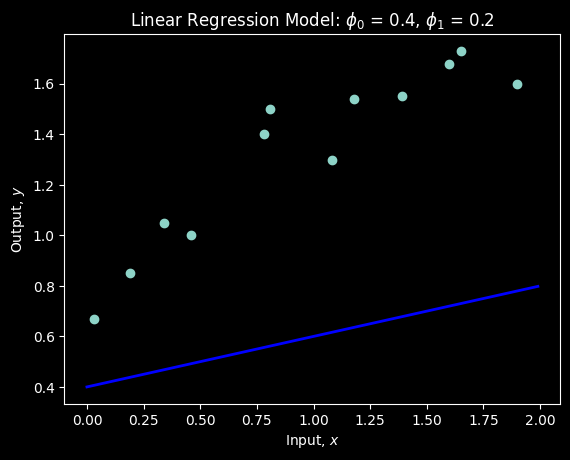

In [15]:
# Set the intercept and slope 
phi0 = 0.4 ; phi1 = 0.2
# Plot the data and the model
plot(X,Y,phi0,phi1)

### Loss

Each choice of parameters $\boldsymbol{\phi}$ yields a measure of how well the model fits the data. This measure is called the loss function, which quantifies the difference between the predicted outputs and the actual outputs in the dataset.


$$
\begin{aligned}
L[\boldsymbol{\phi}]
&= \sum_{i=1}^{I}
\left(f[x_i,\boldsymbol{\phi}]-y_i\right)^2 \\
&= \sum_{i=1}^{I}
\left(\phi_0+\phi_1x_i-y_i\right)^2.
\end{aligned}
\tag{1}
$$


In [17]:
# Function to calculate the loss
def compute_loss(x,y,phi0,phi1):

  predictions = f(x, phi0, phi1)
  squared = (y - predictions)**2
  loss = sum(squared)

  return loss

# Compute the loss for our current model
loss = compute_loss(X, Y, phi0, phi1)
print(f'Your Loss = {loss:3.2f}')

Your Loss = 7.07


Note that the loss function above is not the only possible choice. Other loss functions can be used. 

The one above specifically is called the least-squares loss function, which is the most common choice for linear regression.


<img src="assets/Chap02/SupervisedLinearFitError.svg" style="filter: invert(1);" width="100%">


Linear regression training data, model, and loss. 

* Top left panel: The training data (blue points) consist of $I$ = 12 input/output pairs {$x_i$,$y_i$}. 

* b–d) Each panel shows the linear regression model with different parameters. Depending on the choice of y-intercept and slope parameters $\mathbf{\phi}$= [$\phi_0, \phi_1$], the model errors (blue dashed lines) may be larger or smaller. The loss $\mathcal{L}$ is the sum of the squares of these errors. The parameters that define the lines in panels (b) and (c) have large losses L= 7.07 and L= 10.28, respectively because the models fit badly. The loss L= 0.20 in panel (d) is smaller because the model fits well; in fact, this has the smallest loss of all possible lines, so these are the optimal parameters.
(Interactive figure)


In [18]:
phi0, phi1 = 0.4, 0.2
loss = compute_loss(X, Y, phi0, phi1)
print(f'Loss for phi0={phi0},\tphi1={phi1} is {loss:3.2f}')

phi0, phi1 = 1.6, -0.8
loss = compute_loss(X, Y, phi0, phi1)
print(f'Loss for phi0={phi0},\tphi1={phi1} is {loss:3.2f}')

phi0, phi1 = 0.84, 0.5 
loss = compute_loss(X, Y, phi0, phi1)
print(f'Loss for phi0={phi0},\tphi1={phi1} is {loss:3.2f}')

Loss for phi0=0.4,	phi1=0.2 is 7.07
Loss for phi0=1.6,	phi1=-0.8 is 10.28
Loss for phi0=0.84,	phi1=0.5 is 0.20


Each combination of parameters $\mathbf{\phi}=[\phi_0, \phi_1]$ has an associated loss. The resulting loss function L[$\mathbf{\phi}$] can be visualized as a surface. 

The three circles represent the three lines from figure above. 

<img src="assets/Chap02/SupervisedSurface.svg" style="filter: invert(1);" width="100%">
 

The loss can also be visualized as a heatmap, where brighter regions represent larger losses; here we are looking straight down at the surface in the left panel from above.

The gray ellipses represent isocontours. The best fitting line has the parameters with the smallest loss.


### Training

In linear regression, and generally in other supervised learning models, the parameters $\mathbf{\phi}$ are learned from the data through a process called training. 

The goal is to find the y-intercept and slope parameters $\mathbf{\hat{\phi}}$ that correspond to the smallest loss. 

Iterative training algorithms initialize the parameters randomly and then improve them by “walking downhill” until no further improvement can be made. 
 
$$
\begin{aligned}
\hat{\boldsymbol{\phi}}
&= \operatorname*{arg\,min}_{\boldsymbol{\phi}}
~L[\boldsymbol{\phi}] \\
&= \operatorname*{arg\,min}_{\boldsymbol{\phi}}
\left[
\sum_{i=1}^{I}
\left(
f[x_i,\boldsymbol{\phi}]-y_i
\right)^2
\right] \\
&= \operatorname*{arg\,min}_{\boldsymbol{\phi}}
\left[
\sum_{i=1}^{I}
\left(
\phi_0+\phi_1x_i-y_i
\right)^2
\right].
\end{aligned}
$$

<img src="assets/Chap02/SupervisedOpt.svg" style="filter: invert(1);" width="100%">

Here, we start at position 0 and move
a certain distance downhill (perpendicular to the contours) to position 1. Then we re-calculate the downhill direction and move to position 2. Eventually, we
reach the minimum of the function (position 4). 

Each position 0–4 from panel (a) corresponds to a different y-intercept and slope and so represents a different line in panel (b). As the loss decreases, the lines fit the data more closely. [Interactive figure](https://udlbook.github.io/udlfigures/)


In [23]:
import numpy as np

# Make a 2D grid of possible phi0 and phi1 values
phi0_mesh, phi1_mesh = np.meshgrid(np.arange(0.0,2.0,0.02), np.arange(-1.0,1.0,0.02))

# Make a 2D array for the losses
all_losses = np.zeros_like(phi1_mesh)
# Run through each 2D combination of phi0, phi1 and compute loss
for indices,temp in np.ndenumerate(phi1_mesh):
    all_losses[indices] = compute_loss(X,Y, phi0_mesh[indices], phi1_mesh[indices])

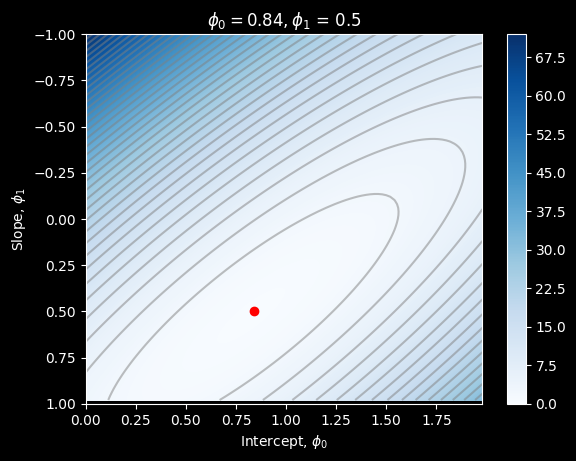

In [28]:
from matplotlib import pyplot as plt 

a = plt.contourf(phi0_mesh, phi1_mesh, all_losses ,levels=256, cmap='Blues')

# adding gray topology lines
plt.contour(phi0_mesh, phi1_mesh, all_losses ,levels=40, colors=['#80808080'])
plt.ylim([1,-1])
plt.xlabel(r'Intercept, $\phi_0$')
plt.ylabel(r'Slope, $\phi_1$')

# Plot the position of your best fitting line on the loss function
# It should be close to the minimum
plt.plot(phi0,phi1,'ro')
plt.title('$\phi_0 = {}, \phi_1$ = {}'.format(phi0, phi1))

plt.colorbar(a)
plt.show()

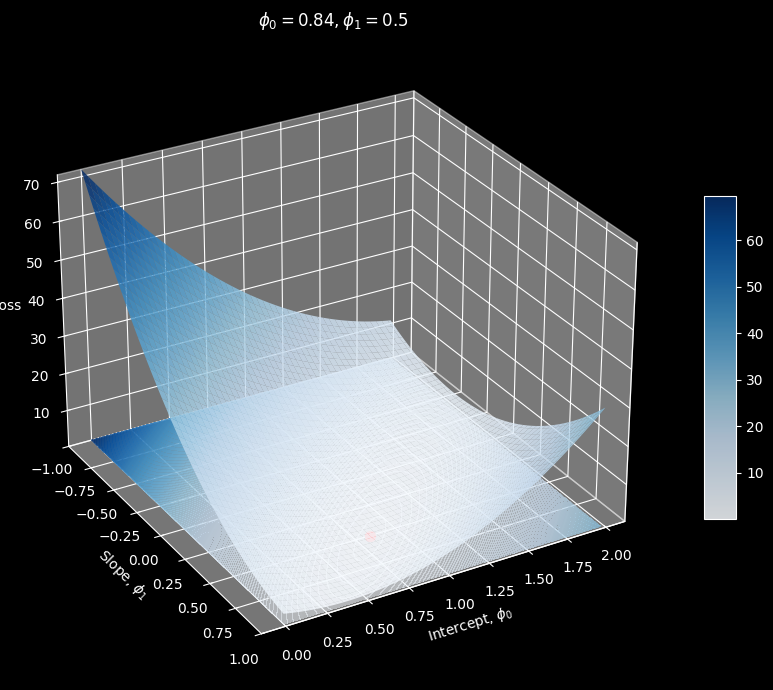

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Create 3D figure and axes
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# 1. 3D Surface Plot
surf = ax.plot_surface(
    phi0_mesh, 
    phi1_mesh, 
    all_losses, 
    cmap='Blues', 
    edgecolor='none', 
    alpha=0.85,
    antialiased=True
)

# 2. Projected 2D contour & topology lines on the bottom plane (offset)
z_min = np.min(all_losses)
ax.contourf(phi0_mesh, phi1_mesh, all_losses, levels=256, cmap='Blues', zdir='z', offset=z_min, alpha=0.5)
ax.contour(phi0_mesh, phi1_mesh, all_losses, levels=40, colors=['#80808080'], zdir='z', offset=z_min)

# 3. Best-fitting parameter point plotted in 3D space
best_loss = all_losses[np.isclose(phi0_mesh, phi0) & np.isclose(phi1_mesh, phi1)][0] # or compute loss directly
ax.scatter([phi0], [phi1], [best_loss], color='red', s=50, label='Best fit $(\phi_0, \phi_1)$')

# Labels and view limits
ax.set_xlabel(r'Intercept, $\phi_0$')
ax.set_ylabel(r'Slope, $\phi_1$')
ax.set_zlabel('Loss')
ax.set_ylim([1, -1])
ax.set_zlim(z_min, np.max(all_losses))

# Title, Colorbar, and Initial Camera Angle
ax.set_title(r'$\phi_0 = {}, \phi_1 = {}$'.format(phi0, phi1))
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
ax.view_init(elev=28, azim=-120)  # Adjust elevation/azimuth to inspect the valley

plt.tight_layout()
plt.show()

## General Linear Model

Note that linear regression is not limited to a single input variable. In general, the model can be expressed as: 

$$
\mathbf{y} = \mathbf{x_1}\boldsymbol{\phi_1} + \mathbf{x_2}\boldsymbol{\phi_2} + \dots + \mathbf{x_n}\boldsymbol{\phi_n} + \boldsymbol{\phi_0}
$$

Below is an example of a 2D linear function, where the output variable $\mathbf{y}$ is a linear combination of two input variables $\mathbf{x_1}$ and $\mathbf{x_2}$, along with a bias term $\boldsymbol{\phi_0}$.


In [30]:
# Define a linear function with two inputs, x1 and x2
def linear_function_2D(x1,x2,beta,omega1,omega2):
  
  y = beta + x1*omega1 + x2*omega2

  return y

In [32]:
# Make 2D array of x and y points
x1 = np.arange(0.0, 10.0, 0.1)
x2 = np.arange(0.0, 10.0, 0.1)
x1,x2 = np.meshgrid(x1,x2)  # https://www.geeksforgeeks.org/numpy-meshgrid-function/

# Compute the 2D function for given values of omega1, omega2
beta = 0.0; omega1 = 1.0; omega2 = -0.5
y  = linear_function_2D(x1,x2,beta, omega1, omega2)

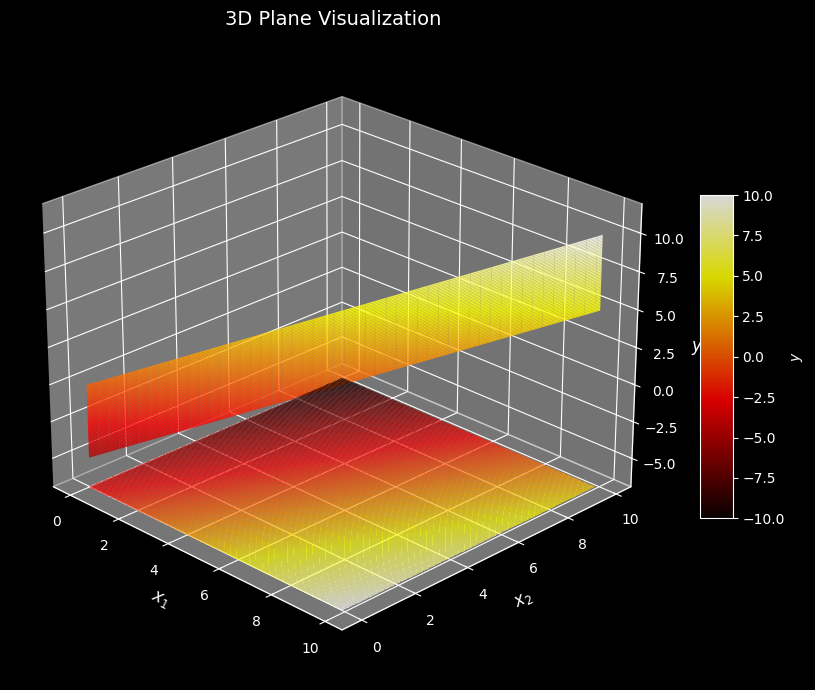

In [33]:
import matplotlib.pyplot as plt
import numpy as np

def draw_3D_function(x1_mesh, x2_mesh, y):
    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot the 3D surface plane
    surf = ax.plot_surface(
        x1_mesh, x2_mesh, y, 
        cmap='hot', 
        vmin=-10.0, vmax=10.0, 
        edgecolor='none', 
        alpha=0.85
    )
    
    # Add 2D contour projection onto the floor (z-min plane)
    z_min = np.min(y) - 2.0
    ax.contourf(x1_mesh, x2_mesh, y, levels=256, zdir='z', offset=z_min, cmap='hot', alpha=0.4)
    ax.set_zlim(z_min, np.max(y) + 2.0)
    
    # Labels
    ax.set_xlabel('$x_1$', fontsize=12)
    ax.set_ylabel('$x_2$', fontsize=12)
    ax.set_zlabel('$y$', fontsize=12)
    ax.set_title('3D Plane Visualization', fontsize=14)
    
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='$y$')
    
    # Set initial camera angle (elevation, azimuth)
    ax.view_init(elev=25, azim=-45)
    
    plt.tight_layout()
    plt.show()

x1 = np.arange(0.0, 10.0, 0.1)
x2 = np.arange(0.0, 10.0, 0.1)
# Example Usage:
draw_3D_function(x1, x2, y)


Below is a 2D projection of the loss function for a linear regression model with two input variables. The loss function is a surface in three dimensions, where the x-axis and y-axis represent the two input variables, and the z-axis represents the loss. 

The color represents the magnitude of the loss, with darker colors indicating higher loss values. The gray lines represent the orie

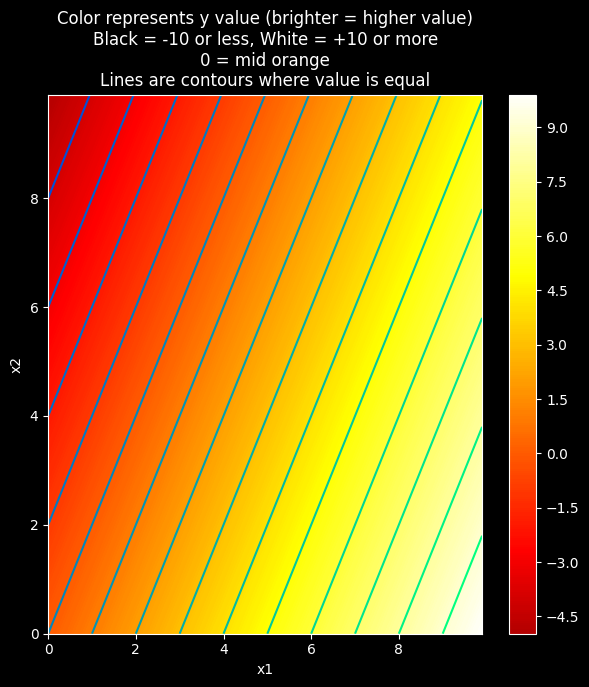

In [ ]:
# Code to draw 2D function -- read it so you know what is going on, but you don't have to change it
def draw_2D_function(x1_mesh, x2_mesh, y):
    fig, ax = plt.subplots()
    fig.set_size_inches(7,7)
    pos = ax.contourf(x1_mesh, x2_mesh, y, levels=256 ,cmap = 'hot', vmin=-10,vmax=10.0)
    fig.colorbar(pos, ax=ax)
    ax.set_xlabel('x1');ax.set_ylabel('x2')
    levels = np.arange(-10,10,1.0)
    ax.contour(x1_mesh, x2_mesh, y, levels, cmap='winter')
    ax.set_title("Color represents y value (brighter = higher value)\nBlack = -10 or less, White = +10 or more\n0 = mid orange\nLines are contours where value is equal")
    plt.show()

# Draw the function.
draw_2D_function(x1,x2,y)

Below is an interactive 3D visualization of the loss function for a linear regression model with two input variables. You can rotate and zoom in on the surface to explore the loss landscape. The red dot represents the optimal parameters that minimize the loss.

In [32]:
import plotly.graph_objects as go

def draw_3D_function_interactive(x1_mesh, x2_mesh, y):
    fig = go.Figure(data=[
        go.Surface(
            x=x1_mesh, 
            y=x2_mesh, 
            z=y, 
            colorscale='Hot',
            cmin=-10, 
            cmax=10
        )
    ])
    
    fig.update_layout(
        title='Interactive 3D Plane Visualization',
        scene=dict(
            xaxis_title='x1',
            yaxis_title='x2',
            zaxis_title='y'
        ),
        width=700,
        height=600
    )
    
    fig.show()

# Example Usage:
draw_3D_function_interactive(x1, x2, y)
